# AquaSense Model Training
## Water Quality Monitoring

This notebook prepares processed sensor data, trains an Isolation Forest for anomaly detection, trains an LSTM forecasting model, and exports deployment artifacts for Raspberry Pi and edge use.

In [1]:
import pandas as pd
from pathlib import Path

csv_path = Path('docs/data/processed/burgas_final.csv')
if not csv_path.exists():
    csv_path = Path('../docs/data/processed/burgas_final.csv')

assert csv_path.exists(), f"Could not find CSV at {csv_path}"
df = pd.read_csv(csv_path, parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
df.head(10)

,time,sea_level_m,temperature_C,dissolved_o2,primary_production,salinity_psu,nitrate,phosphate
0,2022-05-27,0.328140,19.374306,281.69223,26.157421,18.357775,2.534510,0.223134
1,2022-05-28,0.330184,19.374306,281.69223,26.157421,18.345295,2.534510,0.223134
2,2022-05-29,0.331792,19.374306,281.69223,26.157421,18.335102,2.534510,0.223134
3,2022-05-30,0.330618,19.374306,281.69223,26.157421,18.348910,2.534510,0.223134
4,2022-05-31,0.331508,19.374306,281.69223,26.157421,18.337750,2.534510,0.223134
5,2022-06-01,0.331609,19.374306,281.69223,26.157421,18.341210,2.534510,0.223134
6,2022-06-02,0.332889,19.777940,279.61392,25.501020,18.331373,2.721710,0.221322
7,2022-06-03,0.334568,19.615078,278.30310,24.909336,18.325770,2.538669,0.220216
8,2022-06-04,0.335099,19.503020,277.16263,23.227533,18.345700,2.292572,0.224310
9,2022-06-05,0.333900,20.056800,274.47348,23.469288,18.356457,2.428355,0.228117


## 1.1 Define Model Features

Select the four sensor signals used by the model and keep the feature order fixed so scaling, training, and deployment all use the same column layout. This notebook uses `salinity_psu` from the processed CSV.

In [2]:
# Define which features to use for anomaly detection
features = ['temperature_C', 'dissolved_o2', 'salinity_psu', 'sea_level_m']
missing_features = [feature for feature in features if feature not in df.columns]
assert not missing_features, f"Missing expected columns: {missing_features}"
print(f"Features: {features}")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Features: ['temperature_C', 'dissolved_o2', 'salinity_psu', 'sea_level_m']
Dataset shape: (370, 8)
Columns: ['time', 'sea_level_m', 'temperature_C', 'dissolved_o2', 'primary_production', 'salinity_psu', 'nitrate', 'phosphate']


## 1.1 Save Feature List

Save the feature names alongside the model so the Raspberry Pi or any inference script knows the exact input order expected by the trained models.

In [3]:
import json

with open('features_list.json', 'w') as f:
    json.dump(features, f)

print('Saved features_list.json:', features)

Saved features_list.json: ['temperature_C', 'dissolved_o2', 'salinity_psu', 'sea_level_m']


## 1. Load and Explore Data

Load the processed water quality data from CSV and sort by timestamp. This dataset contains sensor readings for temperature, dissolved oxygen, salinity, and sea level.

In [4]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])
joblib.dump(scaler, 'scaler.pkl')  # save this!

['scaler.pkl']

## 2. Normalize Features

Scale all sensor readings to [0, 1] range using MinMaxScaler. This normalization is crucial for the anomaly detection algorithm to treat all features equally, regardless of their original units or scales. The scaler is saved for later use on new data.

In [5]:
split = int(len(scaled) * 0.8)  # 296
train, val = scaled[:split], scaled[split:]

## 3. Train-Validation Split

Split the data into 80% training and 20% validation. Note: For anomaly detection, we train on all data to capture the full range of "normal" behavior.

In [6]:
from sklearn.ensemble import IsolationForest
import joblib

# Train on full scaled data (not just train split —
# you want it to see the full "normal" range)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # assume ~5% anomalies
    random_state=42
)
iso.fit(scaled)
joblib.dump(iso, 'isolation_forest.pkl')

['isolation_forest.pkl']

## 4. Train Isolation Forest Model

**Isolation Forest** is an unsupervised anomaly detection algorithm that works by:
- Randomly selecting features and split values
- Isolating anomalies in fewer steps than normal observations
- Using the number of steps as an anomaly score

**Key Parameters:**
- `n_estimators=100`: Number of isolation trees
- `contamination=0.05`: Expected anomaly percentage (5%)
- `random_state=42`: Reproducibility

In [7]:
# Count threshold violations to estimate contamination
alarm_mask = (
    (df['temperature_C'] > 28) |
    (df['dissolved_o2'] < 4) |
    (df['sea_level_m'].diff() > 0.30)
)
print(f"Alarm fraction: {alarm_mask.mean():.3f}")
# Use this value as contamination

Alarm fraction: 0.000


## 5. Validate Contamination Rate

Check how many readings violate physical thresholds (e.g., temperature too high, dissolved oxygen too low, sea level spikes). This helps validate that our contamination parameter (5%) is reasonable based on domain knowledge.

Saved anomaly plot to anomalies.png


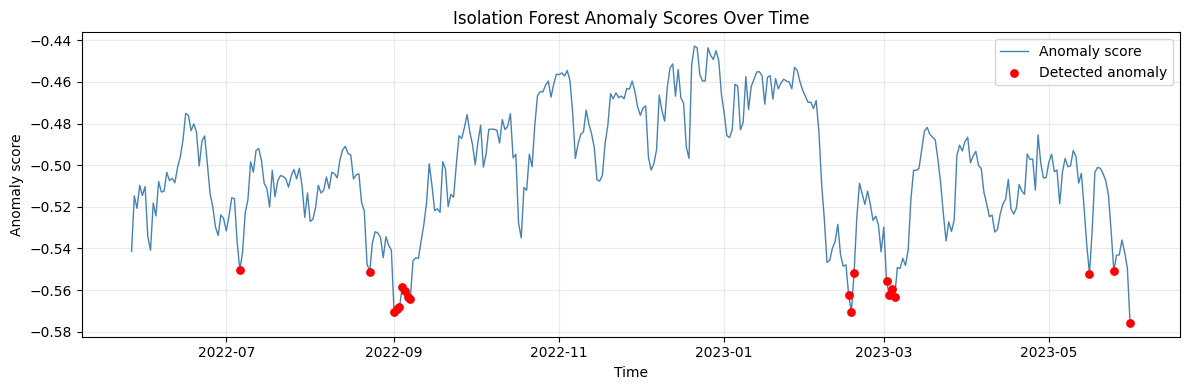

In [8]:
import matplotlib.pyplot as plt
scores = iso.score_samples(scaled)  # more negative = more anomalous
preds = iso.predict(scaled)         # -1 = anomaly, 1 = normal

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['time'], scores, color='steelblue', lw=1.0, label='Anomaly score')
ax.scatter(
    df['time'][preds == -1],
    scores[preds == -1],
    color='red',
    s=28,
    zorder=5,
    label='Detected anomaly',
)
ax.set_title('Isolation Forest Anomaly Scores Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Anomaly score')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig('anomalies.png', dpi=160, bbox_inches='tight')
print('Saved anomaly plot to anomalies.png')

## 6.2 Anomaly Analysis and Reports

Generate human-readable and machine-readable summaries of anomalies detected by the Isolation Forest. This will save:
- `anomalies_summary.png`: time-series with anomalies highlighted
- `anomalies_summary.json`: structured list of anomaly events and reasons
- `anomalies_summary.txt`: plain-text report for quick review

The analysis identifies the most-deviant feature per anomaly (z-score) and checks simple domain thresholds (temp > 28, O2 < 4, sea level spike > 0.30 m).

Saved anomalies_summary.png, anomalies_summary.json, anomalies_summary.txt


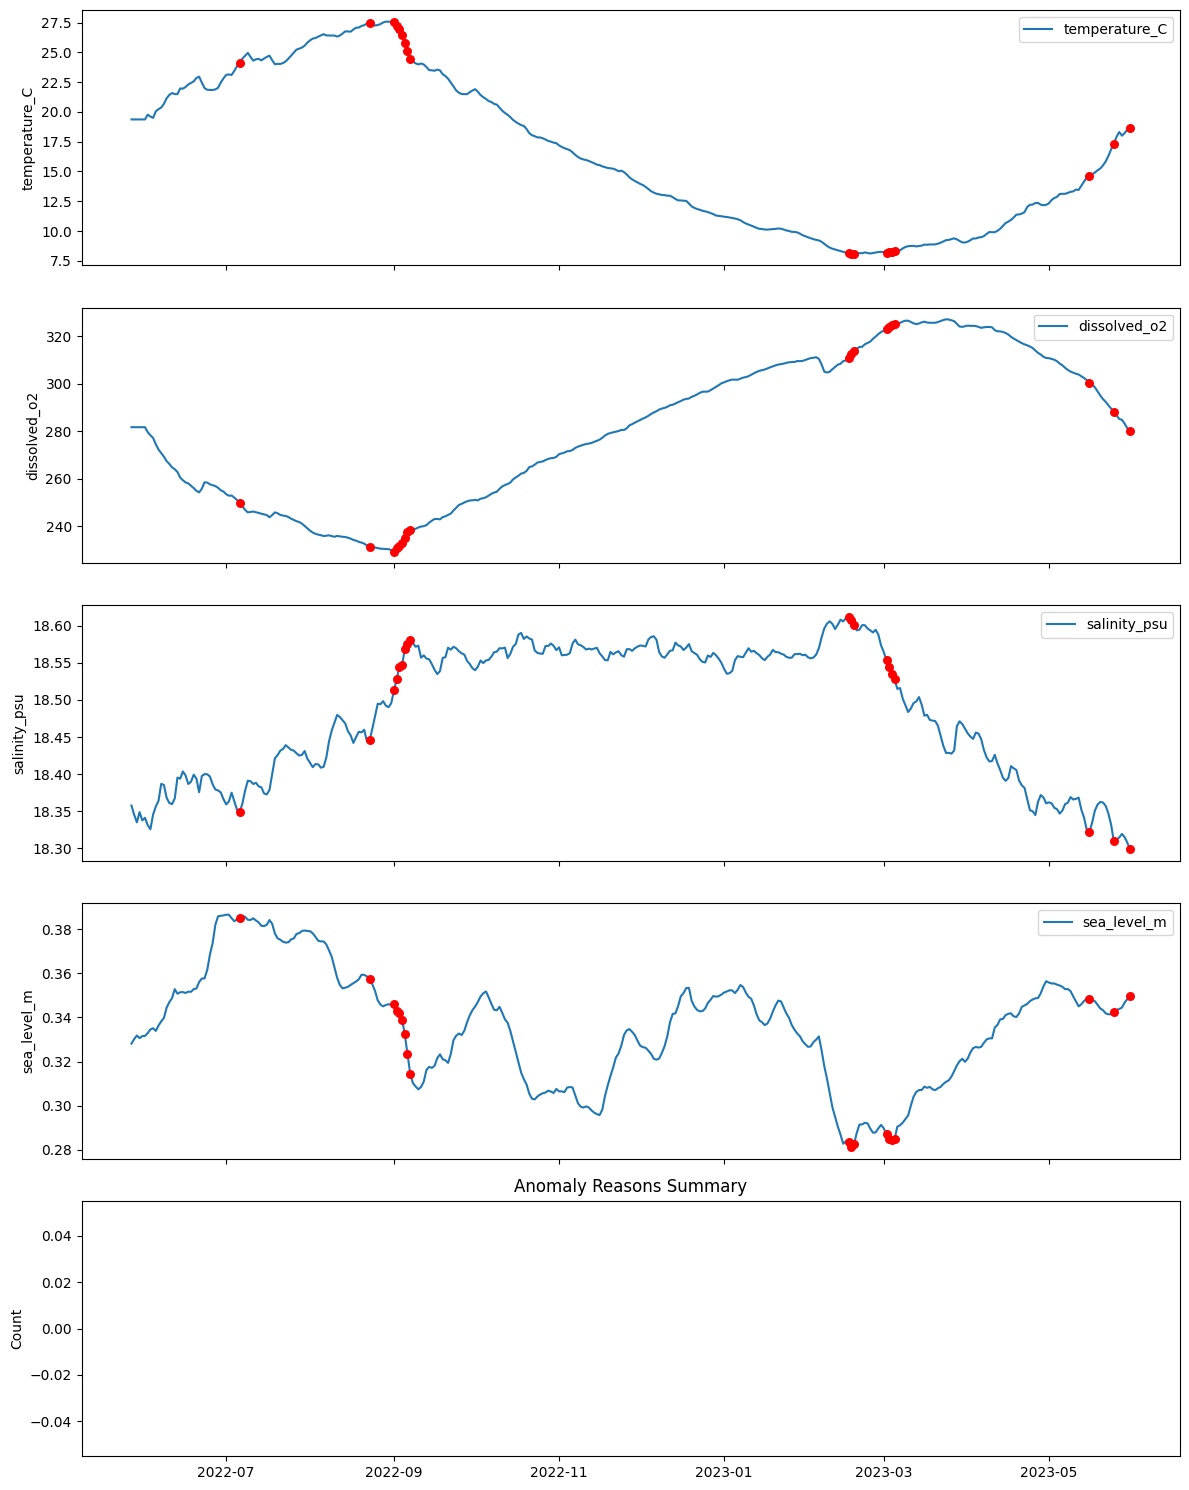

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Create a copy with model outputs
df_out = df.copy()
df_out['iso_score'] = scores
# ensure preds present
try:
    df_out['iso_pred'] = preds
except NameError:
    preds = iso.predict(scaled)
    df_out['iso_pred'] = preds

anoms = df_out[df_out['iso_pred'] == -1].copy()

summary = {
    'total_points': int(len(df_out)),
    'n_anomalies': int(len(anoms)),
    'fraction': float(len(anoms) / len(df_out)) if len(df_out) else 0.0,
    'anomalies': []
}

means = df[features].mean()
stds = df[features].std()

for idx, row in anoms.iterrows():
    feat_values = {f: float(row[f]) for f in features}
    z_scores = ((row[features] - means) / stds).abs()
    top_feat = z_scores.idxmax()
    top_z = float(z_scores[top_feat])
    # domain threshold reasons
    thresholds = {
        'temp_high': bool(row['temperature_C'] > 28),
        'o2_low': bool(row['dissolved_o2'] < 4)
    }
    # sea level spike check relative to previous point
    sea_spike = False
    if idx > 0:
        sea_spike = (row['sea_level_m'] - df.loc[idx - 1, 'sea_level_m']) > 0.30
        thresholds['sea_level_spike'] = bool(sea_spike)
        thresholds['sea_level_diff'] = float(row['sea_level_m'] - df.loc[idx - 1, 'sea_level_m'])
    else:
        thresholds['sea_level_spike'] = False
        thresholds['sea_level_diff'] = 0.0

    summary['anomalies'].append({
        'index': int(idx),
        'time': pd.Timestamp(row['time']).isoformat(),
        'features': feat_values,
        'top_deviating_feature': top_feat,
        'top_z_score': top_z,
        'thresholds': thresholds
    })

# aggregate simple reason counts
reason_counts = Counter()
for a in summary['anomalies']:
    if a['thresholds'].get('temp_high'):
        reason_counts['temp_high'] += 1
    if a['thresholds'].get('o2_low'):
        reason_counts['o2_low'] += 1
    if a['thresholds'].get('sea_level_spike'):
        reason_counts['sea_level_spike'] += 1

summary['reason_counts'] = dict(reason_counts)

# Save JSON and text reports
with open('anomalies_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

with open('anomalies_summary.txt', 'w', encoding='utf-8') as f:
    f.write(f"Total points: {summary['total_points']}\n")
    f.write(f"Anomalies: {summary['n_anomalies']} ({summary['fraction']:.3%})\n\n")
    for a in summary['anomalies']:
        f.write(f"- Time: {a['time']}, Index: {a['index']}, Top dev: {a['top_deviating_feature']} (z={a['top_z_score']:.2f})\n")
        f.write(f"  Thresholds: {a['thresholds']}\n")
        f.write(f"  Values: {a['features']}\n\n")

# Create summary PNG with feature time-series + reason bar chart
fig, axes = plt.subplots(len(features) + 1, 1, figsize=(12, 3 * (len(features) + 1)), sharex=True)
for i, f in enumerate(features):
    axes[i].plot(df['time'], df[f], label=f, color='tab:blue')
    axes[i].scatter(anoms['time'], anoms[f], color='red', s=30, zorder=5)
    axes[i].set_ylabel(f)
    axes[i].legend(loc='upper right')

# bottom bar chart for reason counts
labels = list(summary['reason_counts'].keys())
counts = [summary['reason_counts'].get(k, 0) for k in labels]
axes[-1].bar(labels, counts, color='tab:orange')
axes[-1].set_ylabel('Count')
axes[-1].set_title('Anomaly Reasons Summary')

fig.tight_layout()
fig.savefig('anomalies_summary.png', dpi=160, bbox_inches='tight')
print('Saved anomalies_summary.png, anomalies_summary.json, anomalies_summary.txt')

## 6. Visualize Anomaly Detection Results

Plot the anomaly scores over time:
- **Blue line**: Anomaly score for each timestamp (more negative = more anomalous)
- **Red dots**: Detected anomalies (where the model predicts -1)
- Save visualization as `anomalies.png` for reference

In [10]:
iso = joblib.load('isolation_forest.pkl')
scaler = joblib.load('scaler.pkl')

def check_anomaly(new_reading: dict) -> bool:
    row = scaler.transform([[new_reading[f] for f in features]])
    return iso.predict(row)[0] == -1

## 7. Create Inference Function

Define a reusable function to check if new sensor readings are anomalous:
1. Load the trained model and scaler
2. Normalize the new reading using the same scaler
3. Get prediction from the model (-1 = anomaly, 1 = normal)

**Usage:** Call `check_anomaly()` with a dict of sensor readings to get a boolean result.

## 8. Prepare LSTM Sequences

Turn the scaled tabular data into sliding windows for the LSTM. Each input sample contains 14 timesteps of 4 features, and the target is the next timestep.

In [11]:
import numpy as np

def make_sequences(data, lookback=14):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])   # 14 timesteps of the 4 selected features
        y.append(data[i+lookback])      # next timestep of the same 4 features
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train, lookback=14)
X_val, y_val = make_sequences(val, lookback=14)
# X shape: (N, 14, 4)  - N sequences, 14 timesteps, 4 features

## 9. Build the LSTM Model

Create a compact LSTM network that learns to predict the next water-quality reading from the previous 14 timesteps.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks

model = tf.keras.Sequential([
    layers.Input(shape=(14, 4)),   # 4 features, not 7
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(4)                # predict all 4 features
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,876 (77.64 KB)

 Trainable params: 19,876 (77.64 KB)

 Non-trainable params: 0 (0.00 B)

## 9.1 Train and Save the LSTM

Fit the LSTM with early stopping, then save both a loadable model file and human-readable files so the architecture can be inspected later if needed.

In [13]:
es = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=16,
    callbacks=[es], verbose=1
)

model.save('lstm_aquasense.keras')
model.save_weights('lstm_aquasense.weights.h5')

with open('lstm_aquasense.json', 'w', encoding='utf-8') as f:
    f.write(model.to_json())

with open('lstm_aquasense_summary.txt', 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda line: f.write(line + '\n'))

print('Saved: lstm_aquasense.keras, lstm_aquasense.weights.h5, lstm_aquasense.json, lstm_aquasense_summary.txt')

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.2009 - mae: 0.3611 - val_loss: 0.1011 - val_mae: 0.2760
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0385 - mae: 0.1558 - val_loss: 0.0715 - val_mae: 0.2289
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219 - mae: 0.1167 - val_loss: 0.0448 - val_mae: 0.1741
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0156 - mae: 0.1000 - val_loss: 0.0284 - val_mae: 0.1424
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0124 - mae: 0.0875 - val_loss: 0.0178 - val_mae: 0.1132
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0114 - mae: 0.0850 - val_loss: 0.0202 - val_mae: 0.1178
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0106 - mae: 0.0813 - val_loss: 0.0179 - val_mae: 0.1101
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0094 - mae: 0.0756 - val_loss: 0.0179 - val_mae: 0.1124
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - lo

Saved: lstm_aquasense.keras, lstm_aquasense.weights.h5, lstm_aquasense.json, lstm_aquasense_summary.txt


## 6.1 Export to TensorFlow Lite

Convert the trained Keras model to a lightweight TFLite file for Raspberry Pi deployment. This version enables Select TF ops so the LSTM can convert successfully, and the notebook also saves human-readable model files for inspection.

In [14]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.experimental_enable_resource_variables = True
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('lstm_aquasense.tflite', 'wb') as f:
    f.write(tflite_model)

print(f'TFLite model saved - size: {len(tflite_model)/1024:.1f} KB')
print('Readable exports: lstm_aquasense.json, lstm_aquasense_summary.txt')
print('Loadable exports: lstm_aquasense.keras, lstm_aquasense.weights.h5, lstm_aquasense.tflite')

INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmprhs6u7l_\assets


INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmprhs6u7l_\assets


Saved artifact at 'C:\Users\PC\AppData\Local\Temp\tmprhs6u7l_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 14, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2043813997136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2043813997520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2043813997904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2043813998288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2043813996368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2043813997328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2043813998480: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved - size: 88.1 KB
Readable exports: lstm_aquasense.json, lstm_aquasense_summary.txt
Loadable exports: lstm_aquasense.keras, lstm_aquasense.weights.h5, lstm_aquasense.tflite


## 10. Evaluate the Model

Compare the predicted next-step readings against the validation targets and report the per-feature MAE in the original units.

In [15]:
preds_scaled = model.predict(X_val)
preds_real = scaler.inverse_transform(preds_scaled)
truth_real = scaler.inverse_transform(y_val)

mae_per_feature = np.abs(preds_real - truth_real).mean(axis=0)
mae_table = pd.DataFrame({
    'Feature': features,
    'MAE': mae_per_feature,
})
print('Validation error by feature:')
print(mae_table.to_string(index=False, justify='left', formatters={'MAE': '{:.4f}'.format}))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step
Validation error by feature:
Feature       MAE   
temperature_C 0.4818
 dissolved_o2 3.7650
 salinity_psu 0.0230
  sea_level_m 0.0039


## 11. Live Forecast Cache

Keep a rolling 14-step buffer in memory and refresh the next-step forecast every 5 minutes. This is useful if the model is deployed in a small always-on service.

In [16]:
import threading, time

class ForecastCache:
    def __init__(self, model, scaler, features):
        self.model = model; self.scaler = scaler
        self.features = features; self.buffer = []
        self.forecast = None
        threading.Thread(target=self._loop, daemon=True).start()

    def push(self, reading):
        self.buffer.append([reading[f] for f in self.features])
        if len(self.buffer) > 14: self.buffer.pop(0)

    def _loop(self):
        while True:
            if len(self.buffer) == 14:
                scaled = self.scaler.transform(self.buffer)
                pred = self.model.predict(scaled[np.newaxis])[0]
                self.forecast = self.scaler.inverse_transform([pred])[0]
            time.sleep(300)  # refresh every 5 minutes

## 7.1 Verify Deployment Files

Check that the model artifacts required for Raspberry Pi deployment exist and report their sizes. This is a quick sanity check before copying files to the device.

In [17]:
import os

files = [
    'isolation_forest.pkl',
    'scaler.pkl',
    'lstm_aquasense.keras',
    'lstm_aquasense.tflite',
    'features_list.json'
]

print('Files ready for Pi transfer:')
for file_name in files:
    exists = os.path.exists(file_name)
    size = f"{os.path.getsize(file_name)/1024:.1f} KB" if exists else 'MISSING'
    status = '✓' if exists else '✗'
    print(f"  {status} {file_name:<30} {size}")

Files ready for Pi transfer:
  ✓ isolation_forest.pkl           1733.9 KB
  ✓ scaler.pkl                     1.1 KB
  ✓ lstm_aquasense.keras           263.4 KB
  ✓ lstm_aquasense.tflite          88.1 KB
  ✓ features_list.json             0.1 KB
